# MultiScale CNEEP for SAOU Model

Estimates total exact entropy production (System + Medium EP) across spatial correlation scales.

In [1]:
import sys
import os
CNEEP_V2_ROOT = os.path.abspath('/home/ldh041203/projects/CNEEP_v2')
if CNEEP_V2_ROOT not in sys.path:
    sys.path.append(CNEEP_V2_ROOT)
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'data', 'SAOU'))

from argparse import Namespace
import numpy as np
import torch
from datetime import datetime
from utils.sampler import CartesianSeqSampler
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import joblib
from saou_model import simulate, pathwise_total_epr_increment, build_shell_ops, make_annular_shells, drift, irreversible_velocity_total, theoretical_epr_gram, theoretical_epr_gram_absolute


In [2]:
# Hyper parameters
opt = Namespace()
opt.model_type = 'MultiScaleShellForceCNEEP2D'  # biased ELU force KNEEP: [F(x1, x2) + F(x2, x1)] dot (x2 - x1)
opt.device = 'cuda' if torch.cuda.is_available() else 'cpu'
opt.alpha = -0.5
opt.lam = 0.0
opt.periodic = True
opt.positional = False
opt.n_components = 2
opt.n_iter = 10000
opt.train_batch_size = 2048
opt.test_batch_size = 2048
opt.video_batch_size = 256
opt.lr = 1e-3
opt.wd = 1e-5
opt.input_scalar = 1
opt.loss_scalar = 1
opt.scalar = 1
opt.clip_norm = 1
opt.max_distance = 4
opt.include_k0 = True
opt.beta = 1.0
opt.branch_gain_init = 1.0
# opt.local_rot_gain_init = 1.0
# opt.local_rot_trainable = True
# opt.local_rot_residual = True
opt.local_residual_gain_init = 0.0
# ShellForce-only options below are ignored by MultiScaleK_2DF.
opt.shell_center_mode = 'relative_only'  # 'relative_only', 'gated', or 'add'
opt.shell_force_bias = True
opt.shell_relative_mode = 'learned_absolute'  # 'fixed_sum'/'relative_sum', 'absolute_sum', 'learned', 'learned_absolute', 'learned_sum', or 'learned_absolute_sum'
opt.shell_weight_normalization = 'none'  # 'none' for sum_delta, 'mean' for shell average
opt.shell_force_activation = 'elu'  # 'elu', 'relu', 'tanh', or 'identity'
opt.record_freq = 100
opt.seed = 3
opt.n_layer = 2
opt.n_channel = 8
opt.n_hidden = 2
opt.input_shape = (32, 32)
opt.M = 1000
opt.M_test = 1
opt.L = 1000
opt.L_test = 10000
opt.seq_len = 2
opt.val_ratio = 0.2
opt.time_step = 0.001

# SAOU Parameters
saou_kwargs = dict(
    L=32,
    radii=tuple(range(1, opt.max_distance + 1)),
    amplitudes=(1, 1, 0, 1),
    gamma=1,
    omega0=2,
    T=1e-3,
    dt=1e-4,
    sample_every=1,
    
)
n_steps = opt.L * saou_kwargs['sample_every']
burn_steps = 10000
dt_eff = saou_kwargs['dt'] * saou_kwargs['sample_every']

torch.manual_seed(opt.seed)
np.random.seed(opt.seed)
result_folder = os.path.join(CNEEP_V2_ROOT, 'results')
current_result_folder = os.path.join(result_folder, f'CorrSAOU-{datetime.now().strftime("%Y-%m-%d-%H%M%S")}')
os.makedirs(current_result_folder, exist_ok=True)
current_checkpoint_path = os.path.join(current_result_folder, 'model_parameter.pth.tar')
best_checkpoint_path = os.path.join(current_result_folder, 'best_model_parameter.pth.tar')
print(f'Device: {opt.device}')
print(f'Results: {current_result_folder}')


Device: cuda
Results: /home/ldh041203/projects/CNEEP_v2/results/CorrSAOU-2026-08-26-151510


In [3]:
print(f'[INFO] Generating TRAIN trajectories (M={opt.M}) on {opt.device}...')
res_train = simulate(
    **saou_kwargs,
    n_steps=n_steps,
    burn_steps=burn_steps,
    seed=opt.seed,
    M=opt.M,
    device=opt.device,
    record_trajectory=True,
    show_progress=True
)
traj_train = res_train['trajectory']
if traj_train.ndim == 4: traj_train = traj_train[:, np.newaxis, ...]
trajectories_train = np.transpose(traj_train, (1, 0, 2, 3, 4)) # (M, L, Lx, Ly, 2)
print('Train shape:', trajectories_train.shape)

print(f'[INFO] Generating TEST trajectory (M={opt.M_test}) on {opt.device}...')
test_steps = opt.L_test * saou_kwargs['sample_every']
res_test = simulate(
    **saou_kwargs,
    n_steps=test_steps,
    burn_steps=burn_steps,
    seed=opt.seed + opt.M,
    M=opt.M_test,
    device=opt.device,
    record_trajectory=True,
    show_progress=True
)
traj_test = res_test['trajectory']
if traj_test.ndim == 4: traj_test = traj_test[:, np.newaxis, ...]
trajectories_test = np.transpose(traj_test, (1, 0, 2, 3, 4)) # (M_test, L_test, Lx, Ly, 2)
print('Test shape:', trajectories_test.shape)


[INFO] Generating TRAIN trajectories (M=1000) on cuda...


Train shape: (1000, 1000, 32, 32, 2)
[INFO] Generating TEST trajectory (M=1) on cuda...


Test shape: (1, 10000, 32, 32, 2)


In [4]:
# Reorder channels to (M, L, 2, Lx, Ly) if not already done
if trajectories_train.ndim == 5 and trajectories_train.shape[-1] == 2:
    trajectories_train = np.transpose(trajectories_train, (0, 1, 4, 2, 3))
if trajectories_test.ndim == 5 and trajectories_test.shape[-1] == 2:
    trajectories_test = np.transpose(trajectories_test, (0, 1, 4, 2, 3))

train_val_split_idx = int(opt.M * (1 - opt.val_ratio))
M_train_new = train_val_split_idx
M_val = opt.M - M_train_new

train_video = torch.from_numpy(trajectories_train[:M_train_new]).float().to(opt.device)
val_video = torch.from_numpy(trajectories_train[M_train_new:]).float().to(opt.device)
test_video = torch.from_numpy(trajectories_test).float().to(opt.device)

print('Train video:', train_video.shape)
print('Val video:', val_video.shape)
print('Test video:', test_video.shape)


Train video: torch.Size([800, 1000, 2, 32, 32])
Val video: torch.Size([200, 1000, 2, 32, 32])
Test video: torch.Size([1, 10000, 2, 32, 32])


Model params: 3,130


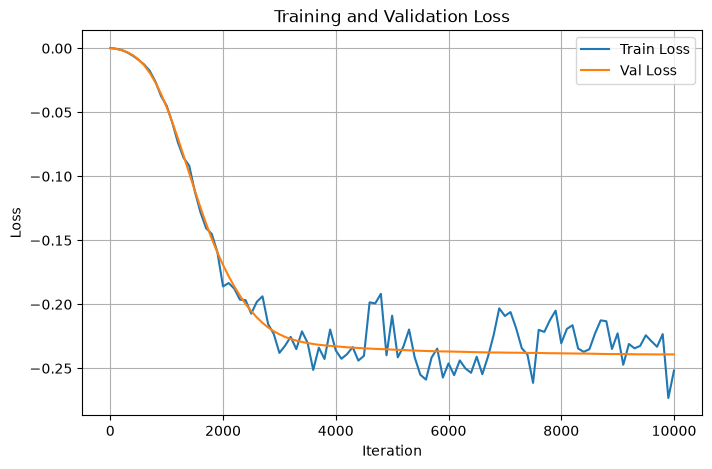

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:29<00:00, 47.63it/s]

Training finished.
Checkpoint saved: /home/ldh041203/projects/CNEEP_v2/results/CorrSAOU-2026-08-26-151510/model_parameter.pth.tar


In [5]:
from models.NEEP_Corr_2D import MultiScaleCNEEP2D
from models.NEEP_Corr_2DF import MultiScaleCNEEP_2DF
from models.NEEP_K_2D import MultiScaleK_2D
from models.NEEP_K_2DF import (
    MultiScaleK_2DF, kneep_local_ep_increment, kneep_normalize_branch_maps,
)
from models.NEEP_K_2DF_TanhGain import MultiScaleK_2DF_TanhGain
from models.NEEP_ShellForce_2D import MultiScaleShellForceCNEEP2D, MultiScaleShellForceCNEEP2D_Tanh
from IPython.display import display

mean = torch.mean(train_video, dim=(0, 1, 3, 4), keepdim=True)
std = torch.std(train_video, dim=(0, 1, 3, 4), keepdim=True)
transform = lambda x: (x - mean.to(x.device)) * opt.input_scalar / std.to(x.device)

if opt.model_type == 'MultiScaleShellForceCNEEP2D_Tanh':
    model = MultiScaleShellForceCNEEP2D_Tanh(opt).to(opt.device)
elif opt.model_type == 'MultiScaleK_2DF_TanhGain':
    model = MultiScaleK_2DF_TanhGain(opt).to(opt.device)
elif opt.model_type == 'MultiScaleShellForceCNEEP2D':
    model = MultiScaleShellForceCNEEP2D(opt).to(opt.device)
elif opt.model_type == 'MultiScaleCNEEP2D':
    model = MultiScaleCNEEP2D(opt).to(opt.device)
elif opt.model_type == 'MultiScaleCNEEP_2DF':
    model = MultiScaleCNEEP_2DF(opt).to(opt.device)
elif opt.model_type == 'MultiScaleK_2D':
    model = MultiScaleK_2D(opt).to(opt.device)
elif opt.model_type == 'MultiScaleK_2DF':
    model = MultiScaleK_2DF(opt).to(opt.device)
else:
    raise ValueError(f'Unknown model_type: {opt.model_type}')

optim = torch.optim.AdamW(model.parameters(), opt.lr, weight_decay=opt.wd)

print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

train_sampler = CartesianSeqSampler(M_train_new, opt.L, opt.seq_len, opt.train_batch_size, device=opt.device)
val_sampler = CartesianSeqSampler(M_val, opt.L, opt.seq_len, opt.test_batch_size, device=opt.device, train=False)

best_val_loss = float('inf')
best_checkpoint_path = os.path.join(current_result_folder, 'best_model_parameter.pth.tar')

smoothing = 0.5
smooth_train_loss = None
smooth_val_loss = None
history_train_loss = []
history_val_loss = []
history_iters = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))
line_train, = ax.plot([], [], label='Train Loss')
line_val, = ax.plot([], [], label='Val Loss')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True)
display_handle = display(fig, display_id=True)
plt.close(fig)


for it in tqdm(range(1, opt.n_iter + 1)):
    model.train()
    batch = next(train_sampler)
    b0 = batch[0].to(train_video.device)
    slices = [train_video[(b0, batch[1][i].to(train_video.device))] for i in range(opt.seq_len)]
    x = transform(torch.stack(slices, dim=1).float().to(opt.device))

    # Stable intensive objective, matching utils.train/utils.validate:
    # spatial mean first, branch sum second.  The transition already includes dt.
    J_all = model(x) / opt.scalar
    spatial_mean_ep = J_all.sum(dim=1)

    optim.zero_grad()
    if opt.alpha == 0:
        loss = (- spatial_mean_ep + (torch.exp(-spatial_mean_ep) - 1)).mean()
    else:
        loss = (- (torch.exp(opt.alpha * spatial_mean_ep) - 1) / opt.alpha
                + (torch.exp(-(1 + opt.alpha) * spatial_mean_ep) - 1) / (1 + opt.alpha)).mean()

    (loss * opt.loss_scalar).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=opt.clip_norm)
    optim.step()

    if it % opt.record_freq == 0 or it == 1:
        model.eval()
        val_loss_acc = 0.0
        n_val = 0
        with torch.no_grad():
            for vb in val_sampler:
                vb0 = vb[0].to(val_video.device)
                vslices = [val_video[(vb0, vb[1][i].to(val_video.device))] for i in range(opt.seq_len)]
                vx = transform(torch.stack(vslices, dim=1).float().to(opt.device))
                vJ = model(vx) / opt.scalar
                v_spatial_mean_ep = vJ.sum(dim=1)
                if opt.alpha == 0:
                    vloss = (- v_spatial_mean_ep + (torch.exp(-v_spatial_mean_ep) - 1)).sum().item()
                else:
                    vloss = (- (torch.exp(opt.alpha * v_spatial_mean_ep) - 1) / opt.alpha
                            + (torch.exp(-(1 + opt.alpha) * v_spatial_mean_ep) - 1) / (1 + opt.alpha)).sum().item()
                val_loss_acc += vloss
                n_val += vx.shape[0]

        avg_val = val_loss_acc / n_val
        
        # Save checkpoint
        state = {
            'settings': opt.__dict__,
            'state_dict': model.state_dict(),
            'optimizer': optim.state_dict(),
            'iteration': it,
        }
        torch.save(state, current_checkpoint_path)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(state, best_checkpoint_path)

        if smooth_train_loss is None:
            smooth_train_loss = loss.item()
            smooth_val_loss = avg_val
        else:
            smooth_train_loss = smoothing * smooth_train_loss + (1 - smoothing) * loss.item()
            smooth_val_loss = smoothing * smooth_val_loss + (1 - smoothing) * avg_val

        history_train_loss.append(smooth_train_loss)
        history_val_loss.append(smooth_val_loss)
        history_iters.append(it)

        line_train.set_data(history_iters, history_train_loss)
        line_val.set_data(history_iters, history_val_loss)
        ax.relim()
        ax.autoscale_view()
        display_handle.update(fig)
print('Training finished.')
print(f'Checkpoint saved: {current_checkpoint_path}')


In [6]:
# Load the Best or Final model
load_best = True  # Set to False to load the model from the final iteration

best_checkpoint_path = os.path.join(current_result_folder, 'best_model_parameter.pth.tar')
if load_best and os.path.exists(best_checkpoint_path):
    print("Loading BEST model (lowest validation loss)...")
    checkpoint = torch.load(best_checkpoint_path, map_location=opt.device)
else:
    print("Loading FINAL iteration model...")
    checkpoint = torch.load(current_checkpoint_path, map_location=opt.device)

model.load_state_dict(checkpoint['state_dict'])
model.eval()
print(f"Loaded model from iteration {checkpoint.get('iteration', 'Unknown')}")

Loading BEST model (lowest validation loss)...
Loaded model from iteration 9700


In [7]:
# Ground Truth Computation
# Calculate System EP + Medium EP explicitly without window summation
shells = make_annular_shells(
    saou_kwargs['radii'],
    saou_kwargs['amplitudes'],
    weight_normalization=saou_kwargs.get('weight_normalization', 'mean'),
)
ops = build_shell_ops(saou_kwargs['L'], shells)
for op in ops:
    op.kernel_hat_t = torch.from_numpy(op.kernel_hat).to(opt.device)
gamma = saou_kwargs['gamma']
T_temp = saou_kwargs['T']
omega0 = saou_kwargs['omega0']
L_size = saou_kwargs['L']

# traj_test_raw shape: (M_test, L_test, L_size, L_size, 2)
traj_test_raw = trajectories_test.transpose(0, 1, 3, 4, 2)

n_windows = opt.L_test - 1
gt_total_epr = np.zeros(n_windows)
gt_epr_map_sum = np.zeros((L_size, L_size))
gt_first_epr_map = None

print('[INFO] Computing GT Exact EP Map for TEST data...')
for t in tqdm(range(n_windows)):
    x0 = traj_test_raw[0, t]     # (Lx, Ly, 2)
    x1 = traj_test_raw[0, t+1]
    x_mid = 0.5 * (x0 + x1)
    dx = x1 - x0
    
    # System Entropy increment: (gamma / 2T) * (|x1|^2 - |x0|^2)
    ds_sys = (gamma / (2.0 * T_temp)) * (np.sum(x1**2, axis=-1) - np.sum(x0**2, axis=-1))
    
    # Medium Entropy increment: (1 / T) * F_total(x_mid) dot dx
    #   F_total = -gamma * x + v_irr(x)
    #   dS_med = (1/T)(-gamma x_mid + v_irr(x_mid)) dot dx
    #         = -(gamma/2T)(|x1|^2 - |x0|^2) + (1/T) v_irr dot dx
    # so that dS_sys + dS_med = (1/T) v_irr dot dx  (correct total EP)
    x_mid_t = torch.from_numpy(x_mid).to(opt.device)
    vel_irr = irreversible_velocity_total(x_mid_t, ops, omega0).cpu().numpy()
    f_total = vel_irr - gamma * x_mid
    ds_med = (1.0 / T_temp) * np.sum(f_total * dx, axis=-1)
    
    # Total local EP
    ds_total = ds_sys + ds_med
    if t == 0:
        gt_first_epr_map = ds_total.copy()
    
    gt_epr_map_sum += ds_total
    gt_total_epr[t] = np.sum(ds_total)

gt_epr_maps = (gt_epr_map_sum / n_windows)[np.newaxis, ...] # (1, Lx, Ly)
print(f'GT mean EP per saved transition: {gt_total_epr.mean():.6e}')


[INFO] Computing GT Exact EP Map for TEST data...


100%|█████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:11<00:00, 907.76it/s]

GT mean EP per saved transition: 2.531348e-01


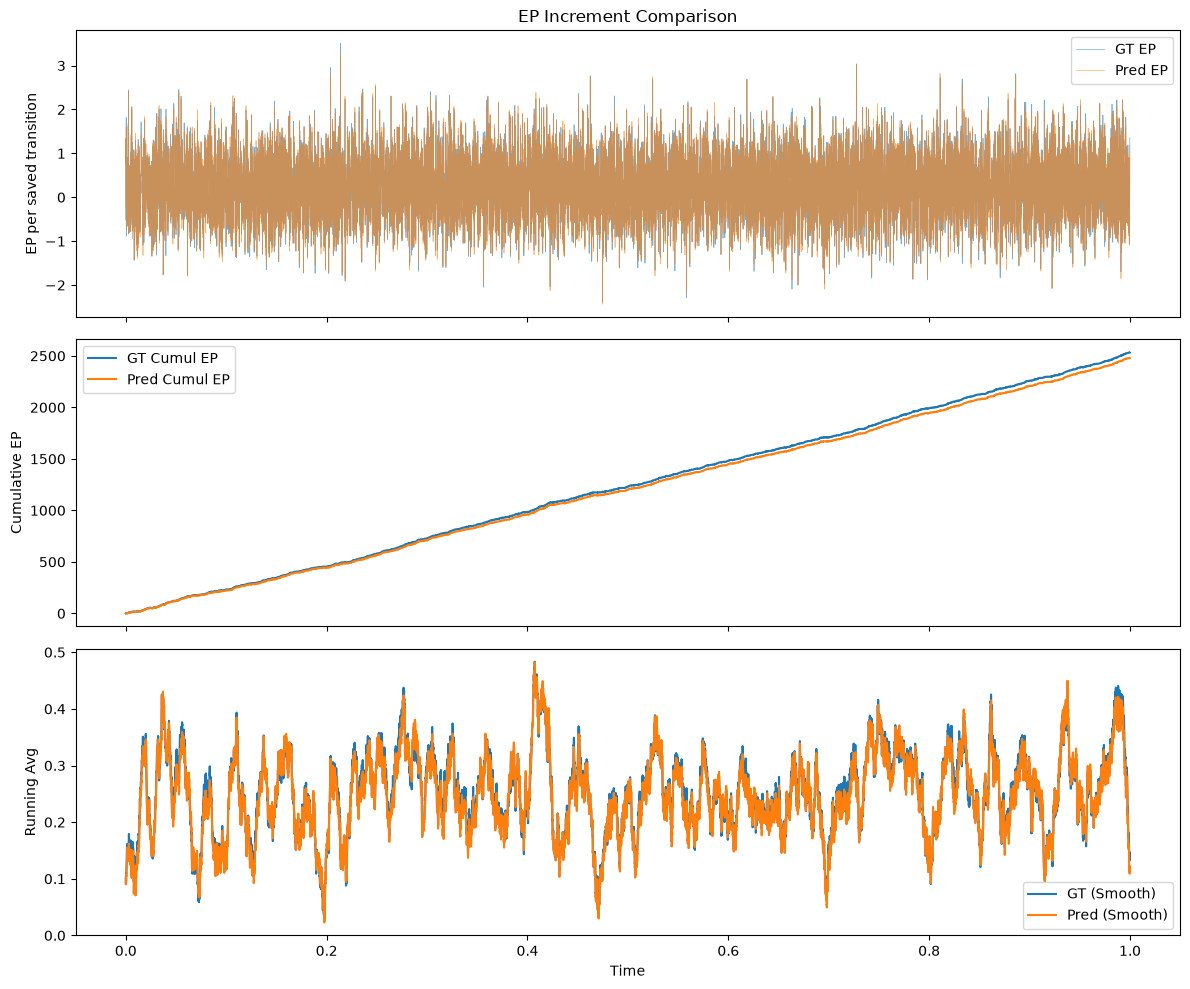

In [8]:
model.eval()
pred_total_ep = []
test_sampler = CartesianSeqSampler(opt.M_test, opt.L_test, opt.seq_len, opt.video_batch_size, device=opt.device, train=False)

with torch.no_grad():
    for batch in test_sampler:
        b0 = batch[0].to(test_video.device)
        slices = [test_video[(b0, batch[1][i].to(test_video.device))] for i in range(opt.seq_len)]
        x = transform(torch.stack(slices, dim=1).float().to(opt.device))
        J_all = model(x) / opt.scalar
        pred_total_ep.append(J_all.sum(dim=1).cpu().numpy()) 

# model(x) already returns branchwise spatial means: no additional /L^2.
pred_total_ep = np.concatenate(pred_total_ep)
min_len = min(len(gt_total_epr), len(pred_total_ep))
time_axis = np.arange(min_len) * dt_eff

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(time_axis, gt_total_epr[:min_len], lw=0.5, alpha=0.6, label='GT EP')
axes[0].plot(time_axis, pred_total_ep[:min_len], lw=0.5, alpha=0.6, label='Pred EP')
axes[0].set_ylabel('EP per saved transition')
axes[0].legend()
axes[0].set_title('EP Increment Comparison')

axes[1].plot(time_axis, np.cumsum(gt_total_epr[:min_len]), label='GT Cumul EP')
axes[1].plot(time_axis, np.cumsum(pred_total_ep[:min_len]), label='Pred Cumul EP')
axes[1].set_ylabel('Cumulative EP')
axes[1].legend()

window = 100
gt_smooth = np.convolve(gt_total_epr[:min_len], np.ones(window)/window, mode='same')
pred_smooth = np.convolve(pred_total_ep[:min_len], np.ones(window)/window, mode='same')
axes[2].plot(time_axis, gt_smooth, label='GT (Smooth)')
axes[2].plot(time_axis, pred_smooth, label='Pred (Smooth)')
axes[2].set_ylabel('Running Avg')
axes[2].set_xlabel('Time')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{current_result_folder}/epr_timeseries.png', dpi=150)
plt.show()


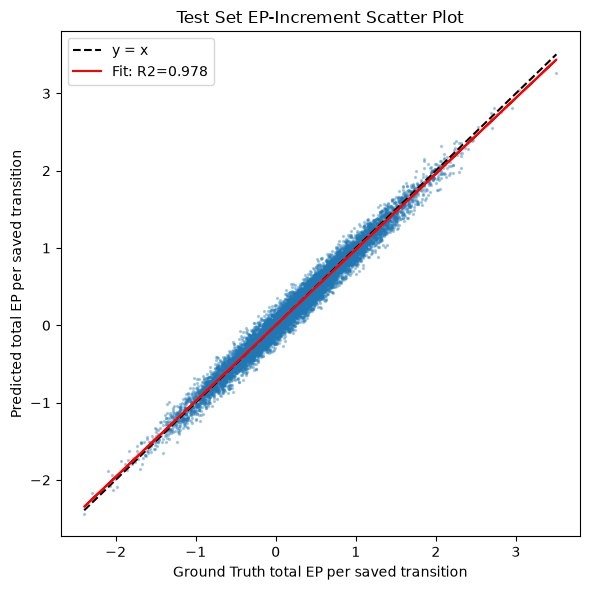

In [9]:
from scipy.stats import linregress
from sklearn.metrics import r2_score

gt_ep = gt_total_epr[:min_len]
pred_ep = pred_total_ep[:min_len] 

slope, intercept, r_value, p_value, std_err = linregress(gt_ep, pred_ep)
r2 = r2_score(gt_ep, pred_ep)

plt.figure(figsize=(6, 6))
plt.scatter(gt_ep, pred_ep, alpha=0.3, s=2)
plt.plot([gt_ep.min(), gt_ep.max()], [gt_ep.min(), gt_ep.max()], 'k--', label='y = x')
plt.plot(gt_ep, intercept + slope * gt_ep, 'r-', label=f'Fit: R2={r2:.3f}')
plt.xlabel('Ground Truth total EP per saved transition')
plt.ylabel('Predicted total EP per saved transition')
plt.title('Test Set EP-Increment Scatter Plot')
plt.legend()
plt.tight_layout()
plt.savefig(f'{current_result_folder}/r2_scatter.png', dpi=150)
plt.show()


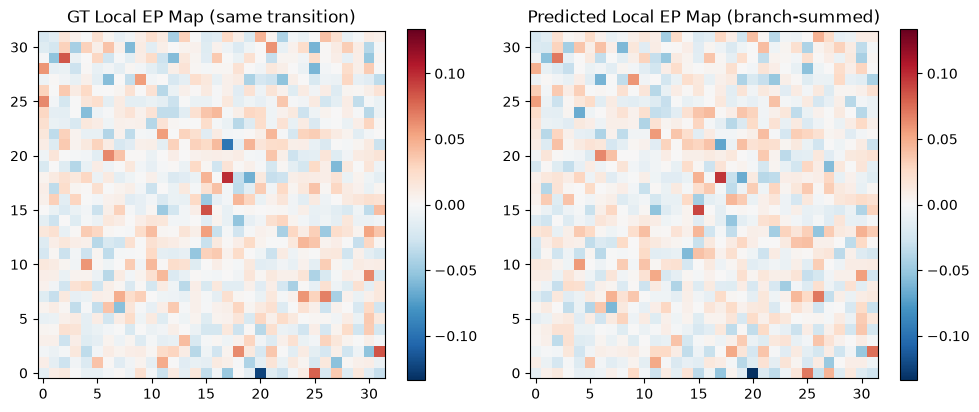

In [10]:
model.eval()
test_sampler_one = CartesianSeqSampler(opt.M_test, opt.L_test, opt.seq_len, 1, device=opt.device, train=False)
ens_idx, traj_idx = next(test_sampler_one)
b0 = ens_idx.to(test_video.device)
slices = [test_video[(b0, traj_idx[i].to(test_video.device))] for i in range(opt.seq_len)]
x = transform(torch.stack(slices, dim=1).float().to(opt.device))

with torch.no_grad():
    raw_maps = model(x, return_maps=True) / opt.scalar
    maps = kneep_normalize_branch_maps(raw_maps)  # [B, K+1, Lx, Ly]
    map_total = maps.sum(dim=(1, 2, 3))
    raw_total = raw_maps.mean(dim=(-2, -1)).sum(dim=1)
    map_consistency_error = (map_total - raw_total).abs().max()
    if map_consistency_error > 5e-5 + 5e-4 * raw_total.abs().max().clamp_min(1.0):
        print(
            '[WARN] Local-map normalization check differs by '
            f'{map_consistency_error.item():.3e}; continuing.'
        )

# return_maps=True is raw: divide every predicted map by L^2, but never by dt.
pred_map_k = maps[0].cpu().numpy() # [K+1, Lx, Ly]
pred_local_map = pred_map_k.sum(axis=0)
# test_sampler_one starts at t=0, so compare the same single transition.
gt_map = gt_first_epr_map

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(np.abs(gt_map).max(), np.abs(pred_local_map).max(), 1e-12)
im1 = axes[0].imshow(gt_map.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('GT Local EP Map (same transition)')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pred_local_map.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('Predicted Local EP Map (branch-summed)')
fig.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{current_result_folder}/local_ep_map_2d.png', dpi=150)
plt.show()


[INFO] Calculating Ensemble Averaged Map...


40it [00:00, 127.50it/s]


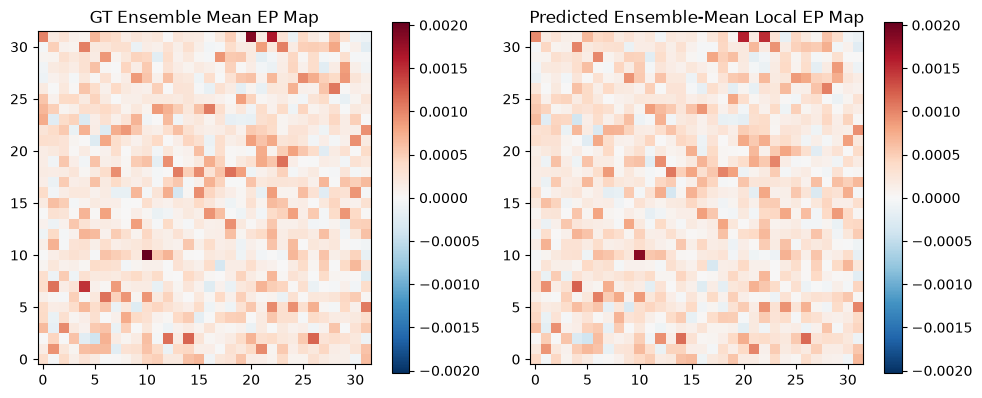

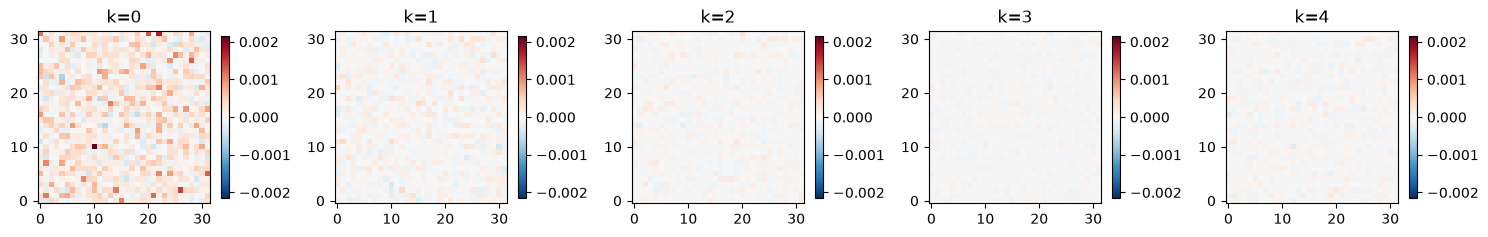

In [11]:
print('[INFO] Calculating Ensemble Averaged Map...')
all_maps = []
test_sampler_batch = CartesianSeqSampler(opt.M_test, opt.L_test, opt.seq_len, opt.video_batch_size, device=opt.device, train=False)

with torch.no_grad():
    for batch in tqdm(test_sampler_batch):
        b0 = batch[0].to(test_video.device)
        vslices = [test_video[(b0, batch[1][i].to(test_video.device))] for i in range(opt.seq_len)]
        vx = transform(torch.stack(vslices, dim=1).float().to(opt.device))
        raw_m = model(vx, return_maps=True) / opt.scalar
        m = kneep_normalize_branch_maps(raw_m)
        all_maps.append(m.cpu().numpy())

all_maps = np.concatenate(all_maps, axis=0) # local EP increment maps
ensemble_map_k = all_maps.mean(axis=0)
ensemble_pred_local_map = ensemble_map_k.sum(axis=0)
ensemble_gt = gt_epr_maps[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(np.abs(ensemble_gt).max(), np.abs(ensemble_pred_local_map).max(), 1e-12)
im0 = axes[0].imshow(ensemble_gt.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('GT Ensemble Mean EP Map')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(ensemble_pred_local_map.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('Predicted Ensemble-Mean Local EP Map')
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{current_result_folder}/ensemble_ep_map_2d.png', dpi=150)
plt.show()

cols = min(opt.max_distance + 1, 6)
rows = int(np.ceil((opt.max_distance + 1) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten() if rows > 1 or cols > 1 else [axes]
from matplotlib.colors import TwoSlopeNorm
spectrum_vmax = max(np.abs(ensemble_map_k).max(), 1e-12)
spectrum_norm = TwoSlopeNorm(vmin=-spectrum_vmax, vcenter=0.0, vmax=spectrum_vmax)
for k in range(opt.max_distance + 1):
    im = axes[k].imshow(ensemble_map_k[k].T, origin='lower', cmap='RdBu_r', norm=spectrum_norm)
    axes[k].set_title(f'k={k}')
    fig.colorbar(im, ax=axes[k], shrink=0.6)
for i in range(opt.max_distance + 1, len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(f'{current_result_folder}/ensemble_ep_map_2d_k.png', dpi=150)
plt.show()


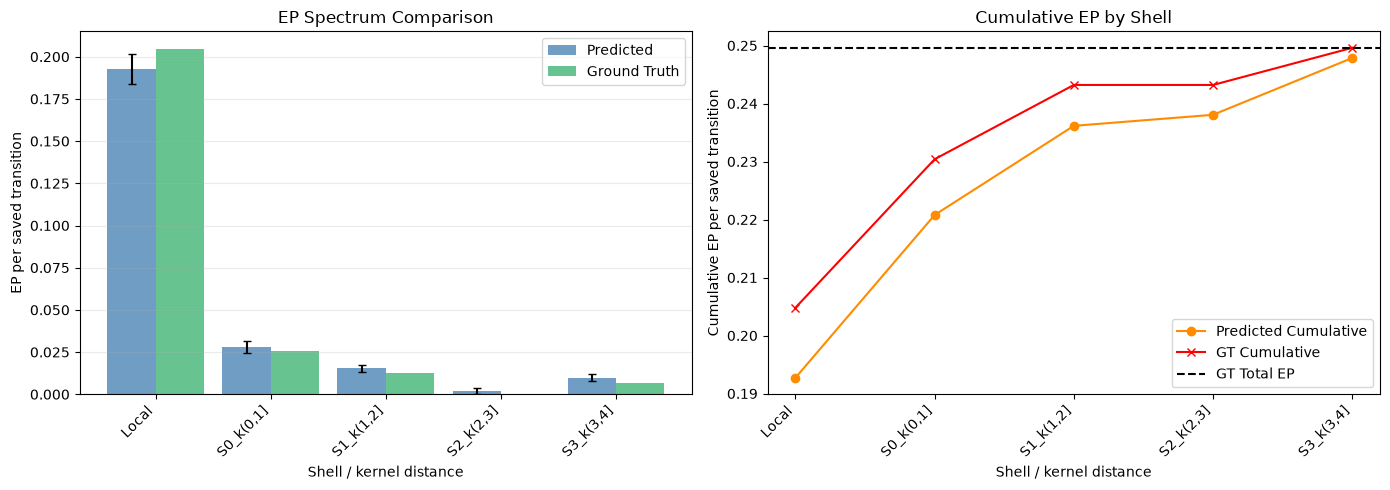

Total predicted EP per saved transition: 2.478451e-01
  k=0: total EP_k = 1.927207e-01 (77.8%)
  k=1: total EP_k = 2.806235e-02 (11.3%)
  k=2: total EP_k = 1.537064e-02 (6.2%)
  k=3: total EP_k = 1.901328e-03 (0.8%)
  k=4: total EP_k = 9.790099e-03 (4.0%)

Total GT EP per saved transition: 2.496000e-01


In [12]:
model.eval()
all_J = []
test_sampler = CartesianSeqSampler(opt.M_test, opt.L_test, opt.seq_len, opt.video_batch_size, device=opt.device, train=False)
with torch.no_grad():
    for batch in test_sampler:
        b0 = batch[0].to(test_video.device)
        slices = [test_video[(b0, batch[1][i].to(test_video.device))] for i in range(opt.seq_len)]
        x = transform(torch.stack(slices, dim=1).float().to(opt.device))
        J = model(x) / opt.scalar
        all_J.append(J.cpu().numpy())

all_J = np.concatenate(all_J, axis=0)
mean_J = all_J.mean(axis=0)
std_J  = all_J.std(axis=0)
distances = np.arange(0, opt.max_distance + 1)

absolute_modes = {
    'absolute_sum', 'absolute', 'abs_sum', 'abs',
    'learned_absolute', 'absolute_learned', 'full_learned_absolute',
    'learned_absolute_sum', 'learned_abs_sum',
    'learned_channelwise_absolute_sum', 'learned_channelwise_absolute',
}
if opt.shell_relative_mode in absolute_modes:
    gt_gram = theoretical_epr_gram_absolute(saou_kwargs['L'], shells, saou_kwargs['gamma'], saou_kwargs['omega0'])
else:
    gt_gram = theoretical_epr_gram(saou_kwargs['L'], shells, saou_kwargs['gamma'], saou_kwargs['omega0'])
# Analytic Gram entries are rates; convert them to EP increments over one
# saved transition before comparing with the raw NEEP output.
gt_components = gt_gram.sum(axis=1) * dt_eff
gt_labels = ['Local'] + [s.name for s in shells]

pred_components = mean_J 
pred_errors = std_J / np.sqrt(len(all_J))
n_bins = max(len(pred_components), len(gt_components))
x = np.arange(n_bins)
bar_width = 0.42
x_labels = [gt_labels[i] if i < len(gt_labels) else f'k={i}' for i in range(n_bins)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x[:len(pred_components)] - bar_width / 2, pred_components, width=bar_width, yerr=pred_errors, capsize=3, alpha=0.78, color='steelblue', label='Predicted')
axes[0].bar(x[:len(gt_components)] + bar_width / 2, gt_components, width=bar_width, alpha=0.78, color='mediumseagreen', label='Ground Truth')
axes[0].set_xlabel('Shell / kernel distance')
axes[0].set_ylabel('EP per saved transition')
axes[0].set_title('EP Spectrum Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

cum_J = np.cumsum(pred_components)
cum_gt = np.cumsum(gt_components)
axes[1].plot(x[:len(cum_J)], cum_J, 'o-', color='darkorange', label='Predicted Cumulative')
axes[1].plot(x[:len(cum_gt)], cum_gt, 'x-', color='red', label='GT Cumulative')
axes[1].axhline(y=gt_components.sum(), color='black', linestyle='--', label='GT Total EP')
axes[1].set_xlabel('Shell / kernel distance')
axes[1].set_ylabel('Cumulative EP per saved transition')
axes[1].set_title('Cumulative EP by Shell')
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{current_result_folder}/ep_spectrum_2d.png', dpi=150)
plt.show()

print(f'Total predicted EP per saved transition: {mean_J.sum():.6e}')
for k in range(opt.max_distance + 1):
    print(f'  k={k}: total EP_k = {mean_J[k]:.6e} ({100 * mean_J[k] / mean_J.sum():.1f}%)')
print(f'\nTotal GT EP per saved transition: {gt_components.sum():.6e}')


/home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Homogeneous reference: T_train=0.001; rollout_T=1e-06; external pin excluded; pinned center omitted from metrics.
[INFO] Force cosine=0.7934, relative RMSE=0.6098
[INFO] Local-EP Pearson r=0.7903, relative RMSE=0.6139
[OK] Saved MP4: /home/ldh041203/projects/CNEEP_v2/results/CorrSAOU-2026-08-26-151510/center_spin_homogeneous_gt_vs_pred_ep.mp4 (14.4 MB)


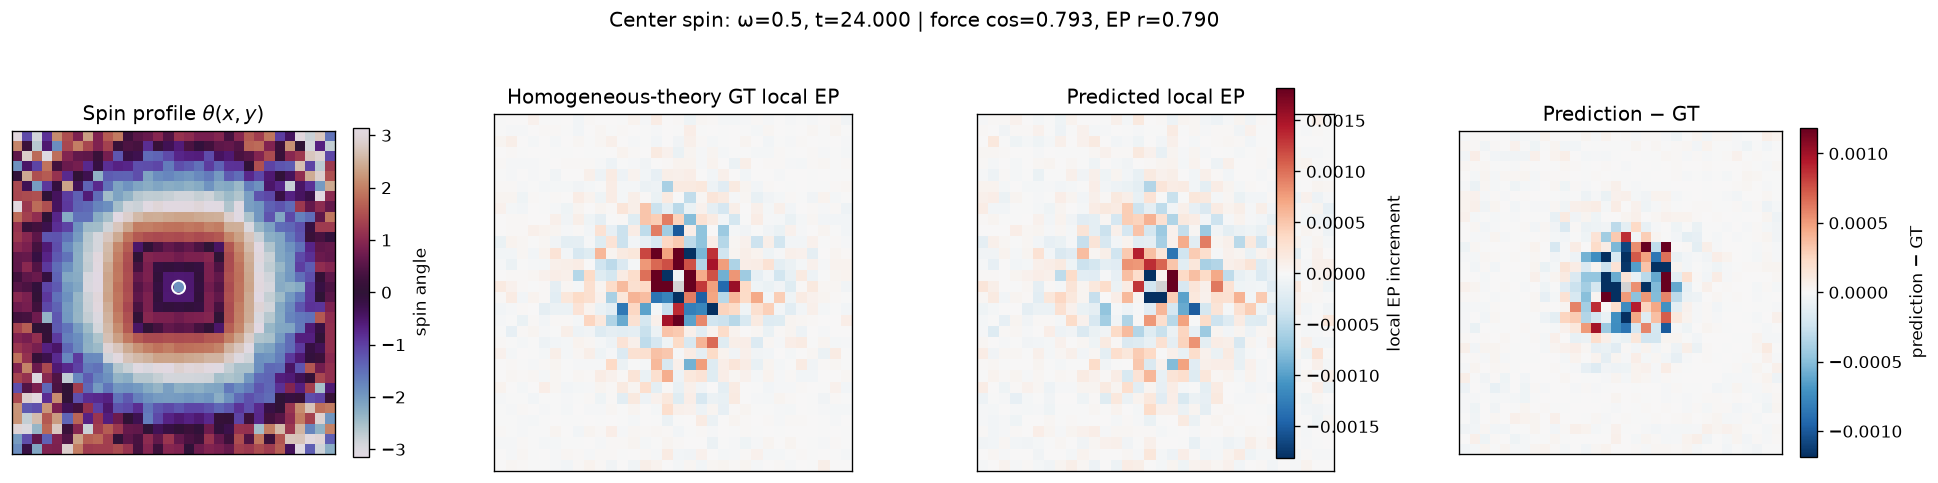

In [13]:
from pathlib import Path
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import animation as mpl_animation
from matplotlib.animation import FuncAnimation
from tqdm.auto import trange

RUN_CENTER_SPIN_EP = True

if RUN_CENTER_SPIN_EP:
    # Parameters
    L = int(saou_kwargs['L'])
    cy = cx = L // 2
    rollout_T, amplitude, pin, omega = 1e-6, 2.5, 40.0, 0.5
    theory_T = float(saou_kwargs['T'])  # homogeneous training reference
    dt = float(saou_kwargs['dt'])
    sample_every = int(saou_kwargs['sample_every'])
    dt_frame = dt * sample_every
    burn_steps, n_transitions = 100_000, 240_000
    seed, fps, max_movie_frames = opt.seed + 10_000, 5, 240

    # SAOU operators
    shells = make_annular_shells(
        saou_kwargs['radii'],
        saou_kwargs['amplitudes'],
        weight_normalization=saou_kwargs.get('weight_normalization', 'mean'),
    )
    ops = build_shell_ops(L, shells)
    for op in ops:
        op.kernel_hat_t = torch.from_numpy(op.kernel_hat).to(
            opt.device, dtype=torch.complex128
        )

    torch.manual_seed(seed)
    x = torch.sqrt(torch.tensor(rollout_T / saou_kwargs['gamma'], device=opt.device)) * torch.randn(
        (L, L, 2), device=opt.device, dtype=torch.float64
    )
    noise_scale = np.sqrt(2.0 * rollout_T * dt)

    def target(t):
        phase = omega * float(t)
        return torch.tensor(
            [amplitude * np.cos(phase), amplitude * np.sin(phase)],
            device=opt.device, dtype=torch.float64,
        )

    def pin_force(state, t):
        force = torch.zeros_like(state)
        force[cy, cx] = pin * (target(t) - state[cy, cx])
        return force

    def advance(state, t):
        state = state + (
            drift(state, ops, saou_kwargs['gamma'], omega0=saou_kwargs['omega0'])
            + pin_force(state, t)
        ) * dt
        return state + noise_scale * torch.randn_like(state)

    # Mask only the pinned center pixel in the output
    yy, xx = np.meshgrid(np.arange(L), np.arange(L), indexing='ij')
    dx = ((xx - cx + L // 2) % L) - L // 2
    dy = ((yy - cy + L // 2) % L) - L // 2
    center_mask = np.sqrt(dx**2 + dy**2) <= 0.0

    # Save only frames needed for the movie
    movie_ids = np.linspace(
        0, n_transitions - 1, min(max_movie_frames, n_transitions), dtype=int
    )
    movie_slot = {int(idx): slot for slot, idx in enumerate(movie_ids)}
    movie_times = (movie_ids + 1) * dt_frame
    spin_frames = np.full((len(movie_ids), L, L, 2), np.nan, dtype=np.float32)
    gt_ep_frames = np.full((len(movie_ids), L, L), np.nan, dtype=np.float32)
    pred_ep_frames = np.full((len(movie_ids), L, L), np.nan, dtype=np.float32)
    gt_force_frames = np.full((len(movie_ids), L, L, 2), np.nan, dtype=np.float32)
    pred_force_frames = np.full((len(movie_ids), L, L, 2), np.nan, dtype=np.float32)

    model.eval()

    # Burn-in
    with torch.no_grad():
        for step in trange(burn_steps, desc='Center-spin burn-in', leave=False):
            x = advance(x, step * dt)

    previous = x.detach().clone()
    pair_batch, id_batch = [], []

    def flush_batch():
        if not pair_batch:
            return

        pairs64 = torch.stack(pair_batch)  # [B, 2, 2, L, L], raw X coordinates
        pairs = pairs64.float()
        with torch.no_grad():
            raw_maps, raw_forces = model(
                transform(pairs), return_maps=True, return_forces=True
            )
            pred_maps = kneep_local_ep_increment(raw_maps / opt.scalar)

            # Convert the learned force conjugate to normalized increments back
            # to the physical homogeneous thermodynamic-force convention.
            std_ch = std.to(pairs.device, pairs.dtype).reshape(1, opt.n_components, 1, 1)
            pred_force = raw_forces.sum(dim=1) * (
                opt.input_scalar / (opt.scalar * L * L)
            ) / std_ch
            dx_raw = pairs[:, 1] - pairs[:, 0]
            # The two sides differ only by float32 operation order:
            # diff(transform(X)) versus transform-scale * diff(X).  Use a
            # scale-aware guard that catches convention errors without failing
            # on O(1e-5) cancellation noise near the strongly pinned center.
            projected_pred_maps = (pred_force * dx_raw).sum(dim=1)
            projection_error = (projected_pred_maps - pred_maps).abs().max()
            projection_scale = pred_maps.abs().max().clamp_min(1.0)
            if projection_error > 5e-5 + 5e-4 * projection_scale:
                print(
                    '[WARN] Learned-force projection differs from the EP map: '
                    f'max_abs_error={projection_error.item():.3e}, '
                    f'scale={projection_scale.item():.3e}. Continuing.'
                )

            # This is deliberately the autonomous homogeneous SAOU reference:
            # exclude the external pin and use the training temperature.  The
            # pinned center is omitted from all comparison metrics and EP maps.
            x_mid = (0.5 * (pairs64[:, 0] + pairs64[:, 1])).permute(0, 2, 3, 1)
            gt_force = irreversible_velocity_total(
                x_mid, ops, omega0=saou_kwargs['omega0']
            ) / theory_T
            gt_maps = (
                gt_force * (pairs64[:, 1] - pairs64[:, 0]).permute(0, 2, 3, 1)
            ).sum(dim=-1)

        pred_maps_np = pred_maps.cpu().numpy()
        pred_force_np = pred_force.permute(0, 2, 3, 1).cpu().numpy()
        gt_maps_np = gt_maps.cpu().numpy()
        gt_force_np = gt_force.cpu().numpy()
        for pred_map, pred_f, gt_map, gt_f, transition_id in zip(
            pred_maps_np, pred_force_np, gt_maps_np, gt_force_np, id_batch
        ):
            slot = movie_slot[transition_id]
            pred_ep_frames[slot] = pred_map
            pred_force_frames[slot] = pred_f
            gt_ep_frames[slot] = gt_map
            gt_force_frames[slot] = gt_f

        pair_batch.clear()
        id_batch.clear()

    # Rollout and trained-model inference
    with torch.no_grad():
        for step in trange(
            n_transitions * sample_every,
            desc='Center-spin rollout + inference',
            leave=False,
        ):
            x = advance(x, (burn_steps + step) * dt)

            if (step + 1) % sample_every:
                continue

            transition_id = (step + 1) // sample_every - 1
            current = x.detach().clone()
            slot = movie_slot.get(transition_id)

            if slot is not None:
                spin_frames[slot] = current.cpu().numpy()
                pair_batch.append(torch.stack((
                    previous.permute(2, 0, 1),
                    current.permute(2, 0, 1),
                )))
                id_batch.append(transition_id)
                if len(pair_batch) >= opt.video_batch_size:
                    flush_batch()

            # Keep consecutive saved states even when this transition is not
            # selected for the movie; only selected pairs need inference.
            previous = current

        flush_batch()

    generated = (spin_frames, gt_ep_frames, pred_ep_frames, gt_force_frames, pred_force_frames)
    if not all(np.all(np.isfinite(array)) for array in generated):
        raise RuntimeError('Some requested movie frames were not generated.')

    # Same-transition local EP increments, with no temporal/spatial averaging.
    # GT and prediction share a scale; only the explicitly pinned center is masked.
    spin_angles = np.arctan2(spin_frames[..., 1], spin_frames[..., 0])
    valid = ~center_mask
    pooled_ep = np.concatenate((gt_ep_frames[:, valid], pred_ep_frames[:, valid]), axis=None)
    diff_ep_frames = pred_ep_frames - gt_ep_frames
    vmax_ep = max(1e-12, float(np.percentile(np.abs(pooled_ep), 99)))
    vmax_diff = max(1e-12, float(np.percentile(np.abs(diff_ep_frames[:, valid]), 99)))

    gt_ep_valid = gt_ep_frames[:, valid].ravel()
    pred_ep_valid = pred_ep_frames[:, valid].ravel()
    ep_corr = float(np.corrcoef(gt_ep_valid, pred_ep_valid)[0, 1])
    ep_rel_rmse = float(
        np.linalg.norm(pred_ep_valid - gt_ep_valid)
        / max(np.linalg.norm(gt_ep_valid), 1e-12)
    )
    gt_force_valid = gt_force_frames[:, valid].reshape(-1, 2)
    pred_force_valid = pred_force_frames[:, valid].reshape(-1, 2)
    force_cosine = float(
        np.vdot(gt_force_valid, pred_force_valid).real
        / max(np.linalg.norm(gt_force_valid) * np.linalg.norm(pred_force_valid), 1e-12)
    )
    force_rel_rmse = float(
        np.linalg.norm(pred_force_valid - gt_force_valid)
        / max(np.linalg.norm(gt_force_valid), 1e-12)
    )
    print(
        f'[INFO] Homogeneous reference: T_train={theory_T:g}; rollout_T={rollout_T:g}; '
        'external pin excluded; pinned center omitted from metrics.'
    )
    print(f'[INFO] Force cosine={force_cosine:.4f}, relative RMSE={force_rel_rmse:.4f}')
    print(f'[INFO] Local-EP Pearson r={ep_corr:.4f}, relative RMSE={ep_rel_rmse:.4f}')

    angle_cmap = plt.get_cmap('twilight').copy()
    ep_cmap = plt.get_cmap('RdBu_r').copy()
    ep_cmap.set_bad('lightgray')

    def masked_ep(frames, i):
        return np.ma.masked_where(center_mask, frames[i])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), dpi=120)
    ax_spin, ax_gt, ax_pred, ax_diff = axes

    spin_im = ax_spin.imshow(
        spin_angles[0], origin='lower', cmap=angle_cmap,
        vmin=-np.pi, vmax=np.pi, interpolation='nearest',
    )
    gt_im = ax_gt.imshow(
        masked_ep(gt_ep_frames, 0), origin='lower', cmap=ep_cmap,
        vmin=-vmax_ep, vmax=vmax_ep, interpolation='nearest',
    )
    pred_im = ax_pred.imshow(
        masked_ep(pred_ep_frames, 0), origin='lower', cmap=ep_cmap,
        vmin=-vmax_ep, vmax=vmax_ep, interpolation='nearest',
    )
    diff_im = ax_diff.imshow(
        masked_ep(diff_ep_frames, 0), origin='lower', cmap=ep_cmap,
        vmin=-vmax_diff, vmax=vmax_diff, interpolation='nearest',
    )

    ax_spin.set_title(r'Spin profile $\theta(x,y)$')
    ax_gt.set_title('Homogeneous-theory GT local EP')
    ax_pred.set_title('Predicted local EP')
    ax_diff.set_title('Prediction − GT')
    ax_spin.scatter([cx], [cy], s=60, facecolors='none', edgecolors='white', linewidths=1.2)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.colorbar(spin_im, ax=ax_spin, fraction=0.046, label='spin angle')
    fig.colorbar(gt_im, ax=[ax_gt, ax_pred], fraction=0.026, pad=0.03, label='local EP increment')
    fig.colorbar(diff_im, ax=ax_diff, fraction=0.046, label='prediction − GT')
    title = fig.suptitle('')

    def update(i):
        spin_im.set_data(spin_angles[i])
        gt_im.set_data(masked_ep(gt_ep_frames, i))
        pred_im.set_data(masked_ep(pred_ep_frames, i))
        diff_im.set_data(masked_ep(diff_ep_frames, i))
        title.set_text(
            f'Center spin: ω={omega:.1f}, t={movie_times[i]:.3f} | '
            f'force cos={force_cosine:.3f}, EP r={ep_corr:.3f}'
        )
        return spin_im, gt_im, pred_im, diff_im, title

    anim = FuncAnimation(
        fig, update, frames=len(movie_ids), interval=1000 / fps, blit=False
    )
    fig.subplots_adjust(left=0.03, right=0.97, bottom=0.08, top=0.84, wspace=0.35)

    # Save an actual MP4.  Singularity may inject GL libraries that break
    # the host ffmpeg, so remove only those entries while ffmpeg is launched.
    output = Path(current_result_folder)
    output.mkdir(parents=True, exist_ok=True)
    mp4_path = output / 'center_spin_homogeneous_gt_vs_pred_ep.mp4'

    def clean_ffmpeg_env():
        old_env = {
            'LD_LIBRARY_PATH': os.environ.get('LD_LIBRARY_PATH'),
            'LD_PRELOAD': os.environ.get('LD_PRELOAD'),
        }
        clean_parts = [
            part for part in os.environ.get('LD_LIBRARY_PATH', '').split(os.pathsep)
            if part and not part.startswith('/.singularity.d/libs')
        ]
        if clean_parts:
            os.environ['LD_LIBRARY_PATH'] = os.pathsep.join(clean_parts)
        else:
            os.environ.pop('LD_LIBRARY_PATH', None)
        os.environ.pop('LD_PRELOAD', None)
        return old_env

    def restore_env(old_env):
        for key, value in old_env.items():
            if value is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = value

    old_env = clean_ffmpeg_env()
    try:
        if not mpl_animation.writers.is_available('ffmpeg'):
            raise RuntimeError(
                'ffmpeg is required to create the requested MP4 but is unavailable.'
            )
        anim.save(
            str(mp4_path),
            writer=mpl_animation.FFMpegWriter(
                fps=fps, bitrate=2400, extra_args=['-pix_fmt', 'yuv420p']
            ),
            dpi=120,
        )
    finally:
        restore_env(old_env)

    if not mp4_path.is_file() or mp4_path.stat().st_size == 0:
        raise RuntimeError(f'MP4 writer returned without creating a valid file: {mp4_path}')
    print(f'[OK] Saved MP4: {mp4_path} ({mp4_path.stat().st_size / 1e6:.1f} MB)')

    plt.show()
else:
    print('Center-spin OOD EP evaluation skipped.')